In [1]:
import pandas as pd

data = pd.read_csv('data.csv')

# Display the first few rows and general information about the dataset
data_info = data.info()
data_head = data.head()

data_info, data_head


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2017 entries, 0 to 2016
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        2017 non-null   int64  
 1   acousticness      2017 non-null   float64
 2   danceability      2017 non-null   float64
 3   duration_ms       2017 non-null   int64  
 4   energy            2017 non-null   float64
 5   instrumentalness  2017 non-null   float64
 6   key               2017 non-null   int64  
 7   liveness          2017 non-null   float64
 8   loudness          2017 non-null   float64
 9   mode              2017 non-null   int64  
 10  speechiness       2017 non-null   float64
 11  tempo             2017 non-null   float64
 12  time_signature    2017 non-null   float64
 13  valence           2017 non-null   float64
 14  target            2017 non-null   int64  
 15  song_title        2017 non-null   object 
 16  artist            2017 non-null   object 


(None,
    Unnamed: 0  acousticness  danceability  duration_ms  energy  \
 0           0        0.0102         0.833       204600   0.434   
 1           1        0.1990         0.743       326933   0.359   
 2           2        0.0344         0.838       185707   0.412   
 3           3        0.6040         0.494       199413   0.338   
 4           4        0.1800         0.678       392893   0.561   
 
    instrumentalness  key  liveness  loudness  mode  speechiness    tempo  \
 0          0.021900    2    0.1650    -8.795     1       0.4310  150.062   
 1          0.006110    1    0.1370   -10.401     1       0.0794  160.083   
 2          0.000234    2    0.1590    -7.148     1       0.2890   75.044   
 3          0.510000    5    0.0922   -15.236     1       0.0261   86.468   
 4          0.512000    5    0.4390   -11.648     0       0.0694  174.004   
 
    time_signature  valence  target      song_title            artist  
 0             4.0    0.286       1        Mask Off  

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Selecting only the numeric columns related to song features for scaling
features = data.select_dtypes(include=['float64', 'int64']).drop(columns=['Unnamed: 0', 'target'])

# Standardizing the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Applying PCA to reduce dimensions while capturing maximum variance (choosing 2 components for visualization)
pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_features)

# Creating a DataFrame with the PCA components for visualization
pca_df = pd.DataFrame(pca_features, columns=['PCA1', 'PCA2'])
pca_df.head()


,PCA1,PCA2
0,-0.281172,-0.937343
1,1.081965,-0.946520
2,0.218285,-1.563584
3,3.652581,-0.378758
4,0.614874,0.466901


c:\Users\syamk\AppData\Local\Programs\Python\Python38\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


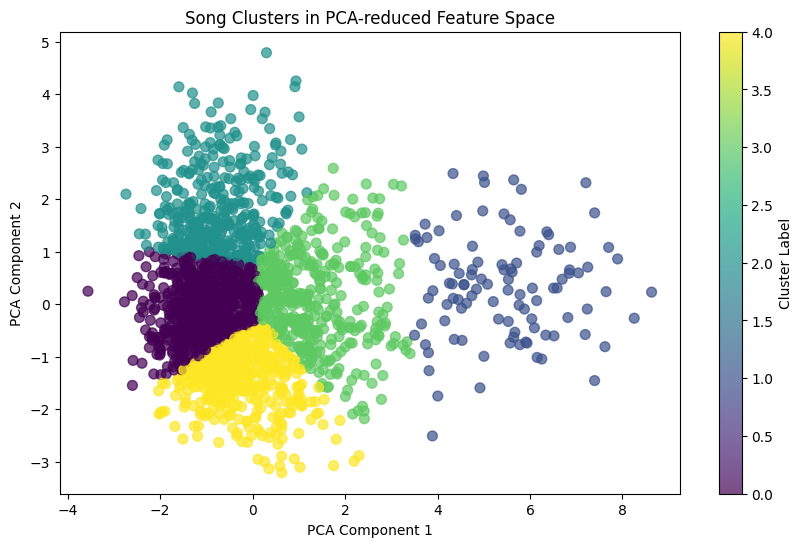

,Unnamed: 0,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,target,song_title,artist,Cluster
0,0,0.0102,0.833,204600,0.434,0.021900,2,0.1650,-8.795,1,0.4310,150.062,4.0,0.286,1,Mask Off,Future,4
1,1,0.1990,0.743,326933,0.359,0.006110,1,0.1370,-10.401,1,0.0794,160.083,4.0,0.588,1,Redbone,Childish Gambino,3
2,2,0.0344,0.838,185707,0.412,0.000234,2,0.1590,-7.148,1,0.2890,75.044,4.0,0.173,1,Xanny Family,Future,4
3,3,0.6040,0.494,199413,0.338,0.510000,5,0.0922,-15.236,1,0.0261,86.468,4.0,0.230,1,Master Of None,Beach House,1
4,4,0.1800,0.678,392893,0.561,0.512000,5,0.4390,-11.648,0,0.0694,174.004,4.0,0.904,1,Parallel Lines,Junior Boys,3


In [3]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Applying K-means clustering with an initial guess of 5 clusters
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(pca_df)

# Adding the cluster labels to the PCA DataFrame
pca_df['Cluster'] = kmeans.labels_

# Visualizing the clusters formed in the PCA-reduced feature space
plt.figure(figsize=(10, 6))
plt.scatter(pca_df['PCA1'], pca_df['PCA2'], c=pca_df['Cluster'], cmap='viridis', s=50, alpha=0.7)
plt.title('Song Clusters in PCA-reduced Feature Space')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster Label')
plt.show()

# Displaying a sample of the clustered data with original features
data_with_clusters = data.copy()
data_with_clusters['Cluster'] = kmeans.labels_
data_with_clusters.head()


In [13]:
import numpy as np

# Example: New song features in the same order as the original dataset
# new_song = np.array(data_with_clusters[['acousticness', 'danceability', 'duration_ms', 'energy',
#                       'instrumentalness', 'key', 'liveness', 'loudness','mode',
#                       'speechiness', 'tempo', 'time_signature', 'valence']])




new_song=[[0.581, 0.825, 233713.0, 0.652, 0.0, 1.0, 0.0931, -3.183, 0.0, 0.0802, 95.977, 4.0, 0.933]] #---happy(4)
#new_song=[[0.202, 0.497, 249640, 0.604, 0, 2, 0.299, -9.438, 1, 0.0313, 131.935, 4, 0.225]]#--sad(3)
#new_song=[[0.0249, 0.683, 201049, 0.824, 0.627, 1, 0.0533, -8.569, 0, 0.222, 154.008, 4, 0.921]] #--sad(3)
#new_song=[[0.0132	,0.807	,330920,	0.778,	0.666,	0,	0.109	,-5.485	,1	,0.0399	,120.001,	4,	0.797]]#---happy(4)

# Step 1: Standardize the new song's features
new_song_scaled = scaler.transform(new_song)

# Step 2: Apply PCA transformation
new_song_pca = pca.transform(new_song_scaled)

# Step 3: Predict the cluster
predicted_cluster = kmeans.predict(new_song_pca)
label={
    0:"",
    1:"Relaxing",
    2:"Energetic",
    3:"sad",
    4:"Happy"
}

print(f"The new song falls into cluster: {label[predicted_cluster[0]]}")




The new song falls into cluster: Happy


c:\Users\syamk\AppData\Local\Programs\Python\Python38\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\syamk\AppData\Local\Programs\Python\Python38\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


In [20]:
# Step 1: Predict clusters for the entire dataset
data_with_clusters['Cluster'] = kmeans.predict(pca_features)

# Step 2: Assign labels to the clusters
label = {
    0:"other",
    1:"Relaxing",
    2:"Energetic",
    3:"Sad",
    4:"Happy"  # Adjust the labels as per your analysis
}

# Step 3: Map the cluster labels to descriptive names
data_with_clusters['Mood'] = data_with_clusters['Cluster'].map(label)

# Step 4: Display the dataset with the new 'Mood' column
print(data_with_clusters.head())

# Optional: Save the labeled dataset to a CSV file
data_with_clusters.to_csv('labeled_songs.csv', index=False)
print("Dataset with mood labels saved as 'labeled_songs_with_moods.csv'.")


   Unnamed: 0  acousticness  danceability  duration_ms  energy  \
0           0        0.0102         0.833       204600   0.434   
1           1        0.1990         0.743       326933   0.359   
2           2        0.0344         0.838       185707   0.412   
3           3        0.6040         0.494       199413   0.338   
4           4        0.1800         0.678       392893   0.561   

   instrumentalness  key  liveness  loudness  mode  speechiness    tempo  \
0          0.021900    2    0.1650    -8.795     1       0.4310  150.062   
1          0.006110    1    0.1370   -10.401     1       0.0794  160.083   
2          0.000234    2    0.1590    -7.148     1       0.2890   75.044   
3          0.510000    5    0.0922   -15.236     1       0.0261   86.468   
4          0.512000    5    0.4390   -11.648     0       0.0694  174.004   

   time_signature  valence  target      song_title            artist  Cluster  \
0             4.0    0.286       1        Mask Off            Fut

c:\Users\syamk\AppData\Local\Programs\Python\Python38\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


In [ ]:
# Step 1: Filter songs labeled as 'Happy'
happy_songs = data_with_clusters[data_with_clusters['Mood'] == 'Happy']

# Step 2: Display the filtered dataset
print("Songs labeled as 'Happy':")
print(happy_songs['song_title'])



Songs labeled as 'Happy':
0                                        Mask Off
2                                    Xanny Family
5                                        Sneakin’
6                                     Childs Play
11                     Donme Dolap - Baris K Edit
                          ...                    
1983                                          Sah
1984                                     Oh Devil
1994                                      Aquaman
2008    Call On Me - EDWYNN X TIKAL, Spirix Remix
2013                                        Candy
Name: song_title, Length: 487, dtype: object
Happy songs saved as 'happy_songs.csv'.
